In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MaxAbsScaler
from scipy.sparse import hstack
from scipy import stats
import re

# Load and prep data (same as notebook 02)
train_df = pd.read_csv('../data/raw/MTS-Dialog-TrainingSet.csv')

section_mapping = {
    'GENHX': 'History', 'FAM/SOCHX': 'History', 'PASTMEDICALHX': 'History',
    'PASTSURGICAL': 'History', 'OTHER_HISTORY': 'History', 'GYNHX': 'History',
    'CC': 'Chief Complaint', 'ROS': 'Exam/Review', 'EXAM': 'Exam/Review',
    'ALLERGY': 'Medications/Allergies', 'MEDICATIONS': 'Medications/Allergies',
    'IMMUNIZATIONS': 'Medications/Allergies',
    'ASSESSMENT': 'Assessment/Diagnosis', 'DIAGNOSIS': 'Assessment/Diagnosis',
    'PLAN': 'Plan/Disposition', 'DISPOSITION': 'Plan/Disposition',
    'EDCOURSE': 'Plan/Disposition', 'PROCEDURES': 'Plan/Disposition',
    'IMAGING': 'Plan/Disposition', 'LABS': 'Plan/Disposition',
}
train_df['section_group'] = train_df['section_header'].map(section_mapping)

#build features
tfidf = TfidfVectorizer(max_features=500, stop_words='english', ngram_range=(1,2), min_df=2, max_df=0.95)
X_tfidf = tfidf.fit_transform(train_df['dialogue'])

def extract_dialogue_features(df):
    features = pd.DataFrame()
    features['word_count'] = df['dialogue'].str.split().str.len()
    features['turn_count'] = df['dialogue'].str.count(r'Doctor:|Patient:|\[doctor\]|\[patient\]')
    features['doctor_words'] = df['dialogue'].apply(
        lambda x: len(' '.join(re.findall(r'(?:Doctor|doctor).*?(?=Patient|patient|$)', x, re.DOTALL)).split()))
    features['patient_words'] = df['dialogue'].apply(
        lambda x: len(' '.join(re.findall(r'(?:Patient|patient).*?(?=Doctor|doctor|$)', x, re.DOTALL)).split()))
    features['avg_turn_length'] = features['word_count'] / features['turn_count'].clip(lower=1)
    return features

X_extra = extract_dialogue_features(train_df)
X_combined = hstack([X_tfidf, X_extra.values])
scaler = MaxAbsScaler()
X_scaled = scaler.fit_transform(X_combined)
y = train_df['section_group']

print(f"Data loaded: {X_scaled.shape[0]} samples, {X_scaled.shape[1]} features")
print(f"Target classes: {sorted(y.unique())}")

Data loaded: 1201 samples, 505 features
Target classes: ['Assessment/Diagnosis', 'Chief Complaint', 'Exam/Review', 'History', 'Medications/Allergies', 'Plan/Disposition']


In [3]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

#define models with best params from tuning
models = {
    'Naive Bayes': ('tfidf', MultinomialNB(alpha=0.1)),
    'Logistic Reg': ('scaled', LogisticRegression(C=0.1, solver='liblinear', class_weight='balanced', random_state=42, max_iter=2000)),
    'SVM (Linear)': ('scaled', SVC(C=0.1, kernel='linear', class_weight='balanced', random_state=42)),
    'Random Forest': ('scaled', RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)),
    'XGBoost': ('scaled', XGBClassifier(n_estimators=100, max_depth=7, learning_rate=0.3, random_state=42, eval_metric='mlogloss')),
}

n_bootstrap = 200
np.random.seed(42)
bootstrap_scores = {name: [] for name in models}

print(f"Running {n_bootstrap} bootstrap iterations per model...\n")
for i in range(n_bootstrap):
    #sample w/ replacement
    idx = np.random.choice(len(y), size=len(y), replace=True)
    oob_idx = list(set(range(len(y))) - set(idx))  #oob samples for testing

    if len(oob_idx) < 10:
        continue

    for name, (data_type, model) in models.items():
        if data_type == 'tfidf':
            X_boot, X_oob = X_tfidf[idx], X_tfidf[oob_idx]
        else:
            X_boot, X_oob = X_scaled[idx], X_scaled[oob_idx]

        if name == 'XGBoost':
            y_boot, y_oob = y_encoded[idx], y_encoded[oob_idx]
        else:
            y_boot, y_oob = y.iloc[idx], y.iloc[oob_idx]

        model.fit(X_boot, y_boot)
        y_pred = model.predict(X_oob)
        score = f1_score(y_oob, y_pred, average='macro', zero_division=0)
        bootstrap_scores[name].append(score)

#print results (95% CI)
print(f"{'Model':<20} {'Mean F1':>10} {'95% CI':>20}")
print("-" * 52)
for name, scores in bootstrap_scores.items():
    mean = np.mean(scores)
    ci_low = np.percentile(scores, 2.5)
    ci_high = np.percentile(scores, 97.5)
    print(f"{name:<20} {mean:>10.3f} {f'[{ci_low:.3f}, {ci_high:.3f}]':>20}")

Running 200 bootstrap iterations per model...

Model                   Mean F1               95% CI
----------------------------------------------------
Naive Bayes               0.431       [0.379, 0.485]
Logistic Reg              0.554       [0.478, 0.616]
SVM (Linear)              0.555       [0.498, 0.613]
Random Forest             0.408       [0.349, 0.472]
XGBoost                   0.493       [0.424, 0.552]


/var/folders/5j/6ll410dd2p50x_mj8rswpbdw0000gn/T/ipykernel_85330/3396068416.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, vert=False)


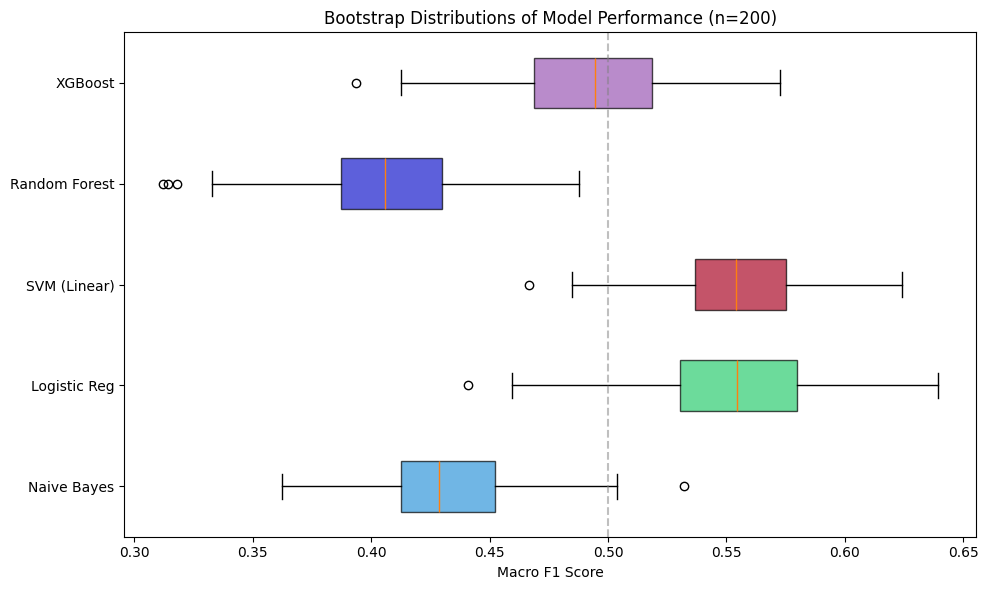

In [6]:
#visualize bootstrap distributions
fig, ax = plt.subplots(figsize=(10, 6))
data_to_plot = [bootstrap_scores[name] for name in bootstrap_scores]
labels = list(bootstrap_scores.keys())

bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, vert=False)
colors = ['#3498db', '#2ecc71', "#ac0c2a", "#191CCD", "#9c5ab6"]
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xlabel('Macro F1 Score')
ax.set_title('Bootstrap Distributions of Model Performance (n=200)')
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='F1 = 0.5')
plt.tight_layout()
plt.show()

In [9]:
#hypothesis testing: Are SVM and logistic reg significantly different
lr_scores = bootstrap_scores['Logistic Reg']
svm_scores = bootstrap_scores['SVM (Linear)']
nb_scores = bootstrap_scores['Naive Bayes']

#paired t-test: Logistic Reg vs SVM
t_stat, p_value = stats.ttest_rel(lr_scores, svm_scores)
print("=== Model Comparison: Logistic Reg vs SVM (Linear) ===")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.3f}")
print(f"Significant at alpha=0.05? {'Yes' if p_value < 0.05 else 'No'}")

#paired t-test: Logistic Reg vs Naive Bayes
t_stat2, p_value2 = stats.ttest_rel(lr_scores, nb_scores)
print(f"\n=== Model Comparison: Logistic Reg vs Naive Bayes ===")
print(f"t-statistic: {t_stat2:.3f}")
print(f"p-value: {p_value2:.3f}")
print(f"Significant at alpha=0.05? {'Yes' if p_value2 < 0.05 else 'No'}")

#kruskal wallis test
#do different section types have significantly different dialogue lengths?
#justifies using dialogue length as a feature

train_df['word_count'] = train_df['dialogue'].str.split().str.len()

#get dialogue lengths grouped by section
groups = [group['word_count'].values for name, group in train_df.groupby('section_group')]
group_names = [name for name, group in train_df.groupby('section_group')]

h_stat, kw_p_value = stats.kruskal(*groups)

print(f"\n=== Kruskal-Wallis Test: Dialogue Length by Section Type ===")
print(f"H-statistic: {h_stat:.3f}")
print(f"p-value: {kw_p_value:.2e}")
print(f"Significant at alpha=0.05? {'Yes' if kw_p_value < 0.05 else 'No'}")

#show median lengths per group for context
print(f"\nMedian dialogue word count by section:")
for name in sorted(group_names):
    subset = train_df[train_df['section_group'] == name]['word_count']
    print(f"  {name:<25} median={subset.median():.0f}  (n={len(subset)})")


#shaprio wilk: Show dialogue lengths are not normally distributed (justifies using Kruskal-Wallis instead of ANOVA)

shapiro_stat, shapiro_p = stats.shapiro(train_df['word_count'].sample(500, random_state=42))
print(f"\n=== Shapiro-Wilk Normality Test (dialogue word count) ===")
print(f"W-statistic: {shapiro_stat:.3f}")
print(f"p-value: {shapiro_p:.2e}")
print(f"Normally distributed? {'Yes' if shapiro_p > 0.05 else 'No - justifies non-parametric test'}")

=== Model Comparison: Logistic Reg vs SVM (Linear) ===
t-statistic: -0.738
p-value: 0.461
Significant at alpha=0.05? No

=== Model Comparison: Logistic Reg vs Naive Bayes ===
t-statistic: 50.772
p-value: 0.000
Significant at alpha=0.05? Yes

=== Kruskal-Wallis Test: Dialogue Length by Section Type ===
H-statistic: 197.475
p-value: 9.85e-41
Significant at alpha=0.05? Yes

Median dialogue word count by section:
  Assessment/Diagnosis      median=50  (n=53)
  Chief Complaint           median=46  (n=77)
  Exam/Review               median=60  (n=83)
  History                   median=82  (n=821)
  Medications/Allergies     median=22  (n=122)
  Plan/Disposition          median=42  (n=45)

=== Shapiro-Wilk Normality Test (dialogue word count) ===
W-statistic: 0.668
p-value: 4.30e-30
Normally distributed? No - justifies non-parametric test


/var/folders/5j/6ll410dd2p50x_mj8rswpbdw0000gn/T/ipykernel_85330/1435533428.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x='word_count', y='section_group', order=order,


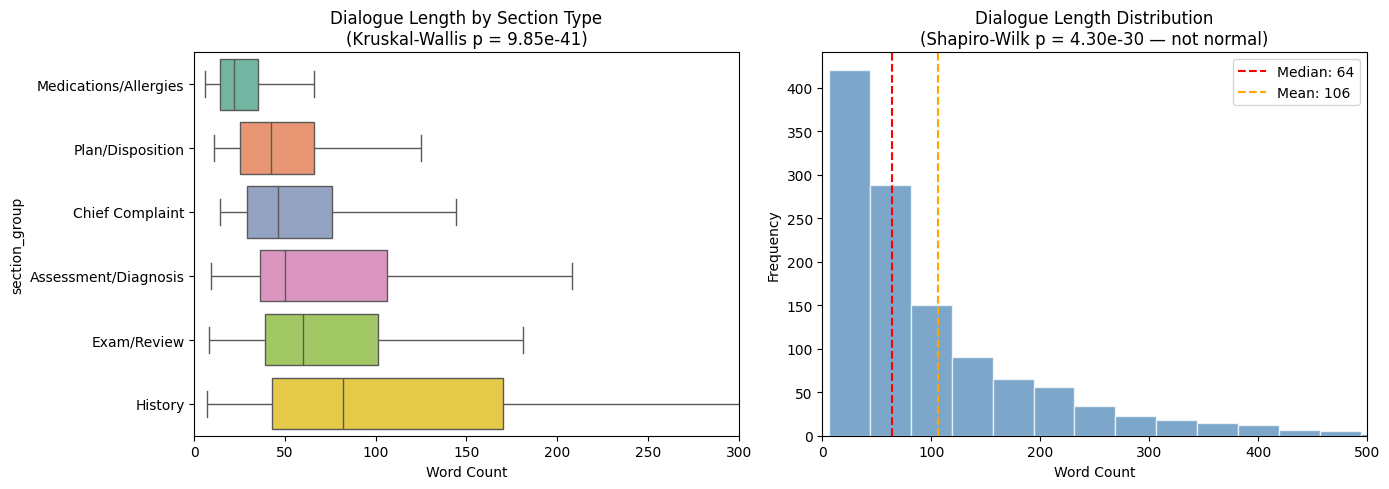

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#left: Cap the x-axis so we can actually see the boxes
order = train_df.groupby('section_group')['word_count'].median().sort_values().index
sns.boxplot(data=train_df, x='word_count', y='section_group', order=order,
            ax=axes[0], palette='Set2', showfliers=False)  #hide outliers
axes[0].set_xlim(0, 300)
axes[0].set_title(f'Dialogue Length by Section Type\n(Kruskal-Wallis p = {kw_p_value:.2e})')
axes[0].set_xlabel('Word Count')

#right: Log scale to handle the skew
axes[1].hist(train_df['word_count'], bins=40, color='steelblue', alpha=0.7, edgecolor='white')
axes[1].set_title(f'Dialogue Length Distribution\n(Shapiro-Wilk p = {shapiro_p:.2e} — not normal)')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].set_xlim(0, 500)
axes[1].axvline(train_df['word_count'].median(), color='red', linestyle='--',
                label=f"Median: {train_df['word_count'].median():.0f}")
axes[1].axvline(train_df['word_count'].mean(), color='orange', linestyle='--',
                label=f"Mean: {train_df['word_count'].mean():.0f}")
axes[1].legend()

plt.tight_layout()
plt.show()